In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
import os

## df_Enamine_t6_t12_wells/controls

In [2]:
df_Enamine_t6_t12_wells=pd.read_csv('/home/ethan2/GrowthNet/data/raw/Enamine_t6_t12_wells.csv')
df_Enamine_t6_t12_controls=pd.read_csv('/home/ethan2/GrowthNet/data/raw/Enamine_t6_t12_ctrls.csv')
df_Enamine_t6_t12_controls = df_Enamine_t6_t12_controls.drop(columns=['Unnamed: 0'], errors='ignore')

df_Enamine_t6_t12_wells=df_Enamine_t6_t12_wells.rename(columns={'t_6': 't_6.24','t_12':'t_12.48'})
df_Enamine_t6_t12_controls=df_Enamine_t6_t12_controls.rename(columns={'t_6': 't_6.24','t_12':'t_12.48'})


df_Enamine_t6_t12_wells['Concentration'] = 50
df_Enamine_t6_t12_controls['Concentration'] = 50

df_Enamine_t6_t12_wells['Control_Label'] = 0


df_Enamine_t6_t12_controls['Control_Label'] = df_Enamine_t6_t12_controls["Compound"].apply(
    lambda x: 1 if x == 'Ciprofloxacin' else -1
)

Ericks_actives=set(df_Enamine_t6_t12_wells[df_Enamine_t6_t12_wells['Activity'] =='Active']['Compound'])

df_Enamine_t6_t12_wells=df_Enamine_t6_t12_wells.drop(columns=['Activity'])


df_Enamine=pd.concat([df_Enamine_t6_t12_controls,df_Enamine_t6_t12_wells], ignore_index=True)

timepoints = sorted([c for c in df_Enamine.columns if c.startswith('t_')],
                    key=lambda s: float(s.split('_')[1]))


df_Enamine = df_Enamine.melt(
        id_vars=['Well', 'Plate_ID', 'Concentration',
               'Compound','Replicate','Control_Label', 'Smiles'],
        value_vars=timepoints,
        var_name='Timepoint',
        value_name='OD'
    )

df_Enamine['Timepoint'] = df_Enamine['Timepoint'] \
                   .str.replace('t_', '', regex=False) \
                   .astype(float)

# Mirror edge wells (cols 02 and 23) to give them more replicate support before
# any per-Well aggregation. Matches the pattern used in normalize_GrowthCurve_2700_cmpds_v2.ipynb.
df_Enamine = augment_specific_columns(df_Enamine)


NameError: name 'augment_specific_columns' is not defined

In [ ]:
df_Enamine

,Well,Plate_ID,Concentration,Compound,Replicate,Control_Label,Smiles,Timepoint,OD
0,A01,1886318-Y12-A081,50,DMSO,OD_A,-1,NaN,0.00,0.000000
1,A02,1886318-Y12-A081,50,Ciprofloxacin,OD_A,1,1CNCCN1c(c2)c(F)cc3c2N(C4CC4)C=C(C3=O)C(=O)O,0.00,0.003213
2,A23,1886318-Y12-A081,50,DMSO,OD_A,-1,NaN,0.00,0.000000
3,A24,1886318-Y12-A081,50,DMSO,OD_A,-1,NaN,0.00,0.000000
4,B01,1886318-Y12-A081,50,DMSO,OD_A,-1,NaN,0.00,0.000000
...,...,...,...,...,...,...,...,...,...
239995,I23,1886318-Y12-A096,50,DMSO,OD_C,-1,NaN,12.48,1.067762
239996,I23,1886318-Y12-A097,50,DMSO,OD_C,-1,NaN,12.48,1.055346
239997,I23,1886318-Y12-A098,50,DMSO,OD_C,-1,NaN,12.48,0.990777
239998,I23,1886318-Y12-A099,50,DMSO,OD_C,-1,NaN,12.48,1.170716


# Functions

In [3]:
def plot_activity_ratio_heatmap(df):
    # 1) Determine the exact list of concentrations and timepoints, in sorted order
    conc_values = sorted(df['Concentration'].unique())
    time_values = sorted(df['Timepoint'].unique())

    # 2) Build the “total” and “active” count tables, then reindex so they share the same shape/order
    total_counts = (
        df
        .groupby(['Concentration', 'Timepoint'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=conc_values, columns=time_values, fill_value=0)
    )

    active_counts = (
        df[df['is_Active'] == 1]
        .groupby(['Concentration', 'Timepoint'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=conc_values, columns=time_values, fill_value=0)
        .astype(int)
    )

    # 3) Compute fraction = active / total (avoiding division by zero)
    fraction = active_counts.divide(total_counts.replace(0, 1))
    fraction = fraction.fillna(0)

    # 4) Prepare annotation strings “active/total”
    annot = active_counts.astype(str) + "/" + total_counts.astype(str)

    # 5) Plot
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        fraction,
        annot=annot,
        fmt="",
        cmap="viridis",
        cbar_kws={'label': 'Fraction Active'}
    )

    # 6) Set the x‐ and y‐tick labels to the string versions of the numeric values
    ax.set_xticklabels([str(x) for x in time_values])
    ax.set_yticklabels([str(x) for x in conc_values], rotation=0)

    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Concentration')
    ax.set_title('Active / Total Compounds (Test set)')

    plt.tight_layout()
    plt.show()


In [4]:
def label_inactives_actives(df_long: pd.DataFrame, mad_multiplier) -> pd.DataFrame:
    
    def _compute_thresh(group):
        # isolate negative controls
        dmso = group.loc[group['Control_Label'] == -1, 'OD']
        if len(dmso) > 0:
            med = dmso.median()
            mad = 1.4826 * np.median(np.abs(dmso - med))
        else:
            med = group['OD'].median()
            mad = 1.4826 * np.median(np.abs(group['OD'] - med))
        return med - mad_multiplier * mad

   
    thresholds = (
        df_long
        .groupby(['Plate_ID', 'Concentration', 'Timepoint'])
        .apply(_compute_thresh)
        .reset_index(name='threshold')
    )

    
    combined = (
        df_long
        .drop(columns=['threshold'], errors='ignore')  # in case it existed
        .merge(thresholds, on=['Plate_ID', 'Concentration', 'Timepoint'], how='left')
    )

    # 4) Label active/inactive
    combined['is_Active'] = (combined['OD'] < combined['threshold']).astype(int)

    combined.drop(columns=['threshold'], inplace=True)  

    return combined

In [5]:
def plot_sample_counts_per_well(
    df,
    well_col: str = 'Well',
    rows: list[str] = None,
    cols: list[int] = None,
    figsize: tuple[int,int] = (12, 6),
    title: str = 'Sample Counts per Well',
    cmap: str = 'viridis'
):

    # defaults for full 16×24 plate
    if rows is None:
        rows = [chr(c) for c in range(ord('A'), ord('P')+1)]
    if cols is None:
        cols = list(range(1, 25))

    # build the count matrix
    counts = df[well_col].value_counts()
    mat = np.zeros((len(rows), len(cols)), dtype=int)
    for i, r in enumerate(rows):
        for j, c in enumerate(cols):
            well = f"{r}{c:02d}"
            mat[i, j] = counts.get(well, 0)

    # plot
    fig, ax = plt.subplots(figsize=figsize)
    cax = ax.imshow(mat, origin='upper', aspect='equal', cmap=cmap)
    max_val = mat.max()

    # annotate with counts
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            color = 'white' if mat[i, j] > max_val/2 else 'black'
            ax.text(j, i, mat[i, j], ha='center', va='center', color=color)

    # axis labels
    ax.set_xticks(np.arange(len(cols)))
    ax.set_xticklabels(cols)
    ax.set_yticks(np.arange(len(rows)))
    ax.set_yticklabels(rows)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    ax.set_title(title)

    # colorbar
    fig.colorbar(cax, ax=ax, label='Count')
    plt.tight_layout()
    plt.show

In [6]:
def plot_aggregated_heatmaps_long(
    correct_uncorrect,
    dataset,
    df_long,
    timepoint,
    vmin=None,
    vmax=None,
    max_cols=3,
    cmap='viridis',
    figsize_per_subplot=(5, 4),
    save_path=False,
):
    """
    Aggregates median OD values at a given timepoint across all plates,
    then plots one heatmap per concentration using long-format DataFrame.
    Removed DMSO overlay.
    """
    concs = sorted(df_long['Concentration'].dropna().unique())

    if vmin is None or vmax is None:
        all_medians = []

        for conc in concs:
            sub = df_long[
                (df_long['Concentration'] == conc) &
                (df_long['Timepoint']     == timepoint)
            ]
            # median OD per well for this concentration
            med_vals = (
                sub.groupby('Well')['OD']
                   .median()
                   .values                     # numpy array of medians
            )
            all_medians.extend(med_vals)

        all_medians = np.array(all_medians, dtype=float)

        if vmin is None:
            vmin = np.nanmin(all_medians)
        if vmax is None:
            vmax = np.nanmax(all_medians)

    
    n = len(concs)
    ncols = min(max_cols, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_subplot[0] * ncols, figsize_per_subplot[1] * nrows),
        constrained_layout=True
    )
    axes = np.atleast_1d(axes).flatten()

    for ax, conc in zip(axes, concs):
        sub = df_long[
            (df_long['Concentration'] == conc) &
            (df_long['Timepoint'] == timepoint)
        ]

        # compute median OD per well
        med = sub.groupby('Well')['OD'].median().reset_index(name='MedianOD')
        med['Row'] = med['Well'].str[0]
        med['Col'] = med['Well'].str[1:].astype(int)
        heatmap_data = med.pivot(index='Row', columns='Col', values='MedianOD')

        # draw heatmap
        im = sns.heatmap(
            heatmap_data,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            cbar=False,
            square=True
        )

        # annotate number of plates
        num_plates = sub['Plate_ID'].nunique()
        ax.set_title(f'{conc} µM ({num_plates} plates)')
        ax.set_xlabel('Col')
        ax.set_ylabel('Row')

    # turn off unused subplots
    for ax in axes[len(concs):]:
        ax.axis('off')

    # shared colorbar
    mappable = axes[0].collections[0]
    fig.colorbar(
        mappable,
        ax=axes.tolist(),
        orientation='vertical',
        fraction=0.02,
        pad=0.04,
        label=f'OD @ {timepoint}'
    )

    plt.suptitle(f'{dataset} {correct_uncorrect}: Median @ {timepoint}', y=1.02)
    
    if save_path:
        plt.savefig(f'/Users/ethankreuzer/Desktop/UdeM/MILA/GrowthCurvePlots/well_medians/{dataset}/{correct_uncorrect}_OD_dist/{correct_uncorrect}_heatmap_{timepoint}.png')

    else:
        plt.show()

In [7]:
def correct_well_batch_effect_time_conc(df_long):
    """
    Multiplicative well-level batch correction.

    For each (Well, Timepoint, Concentration), compute the median OD over rows
    currently labelled inactive (`is_Active == 0`) and rescale every row at that
    spot by `global_median(T, C) / well_median(T, C)`. Skips Timepoint == 0.

    Caller must populate `is_Active` first (the iterator does this).
    """
    inactive = df_long[df_long['is_Active'] == 0]

    well_medians = (
        inactive
        .groupby(['Well', 'Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='well_meds')
    )

    global_medians = (
        inactive
        .groupby(['Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='global_meds')
    )

    df = df_long.merge(well_medians, on=['Well', 'Timepoint', 'Concentration'], how='left')
    df = df.merge(global_medians, on=['Timepoint', 'Concentration'], how='left')

    mask = df['Timepoint'] != 0
    df.loc[mask, 'OD'] = (
        df.loc[mask, 'OD']
        / df.loc[mask, 'well_meds']
        * df.loc[mask, 'global_meds']
    )

    df = df.drop(columns=['well_meds', 'global_meds'])
    return df, global_medians, well_medians


In [8]:
def correct_plate_batch_effect_dmso(df: pd.DataFrame) -> pd.DataFrame:
    """
    Plate-level batch correction using DMSO wells as the reference.

    Divides each OD by its plate's DMSO median and multiplies by the global DMSO
    median at the same (Timepoint, Concentration). Preserves the OD scale — since
    the global DMSO median grows with time, corrected OD values also grow with time —
    while removing plate-to-plate offset. Skips Timepoint == 0.

    No iteration needed: DMSO labels are fixed by design, so there is no circularity
    between labels and the correction factor.
    """
    dmso = df[df['Control_Label'] == -1]

    plate_meds = (
        dmso
        .groupby(['Plate_ID', 'Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='plate_dmso_med')
    )

    global_meds = (
        dmso
        .groupby(['Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='global_dmso_med')
    )

    df_norm = df.merge(plate_meds, on=['Plate_ID', 'Timepoint', 'Concentration'], how='left')
    df_norm = df_norm.merge(global_meds, on=['Timepoint', 'Concentration'], how='left')

    denom = df_norm['plate_dmso_med'].to_numpy()
    numer = df_norm['global_dmso_med'].to_numpy()

    mask = (
        (df_norm['Timepoint'] != 0)
        & (denom > 0)
        & np.isfinite(denom)
        & np.isfinite(numer)
    )
    df_norm.loc[mask, 'OD'] = df_norm.loc[mask, 'OD'] * numer[mask] / denom[mask]

    df_norm = df_norm.drop(columns=['plate_dmso_med', 'global_dmso_med'])
    return df_norm

In [9]:
def plot_hist_od_distributions_long(
    title,
    correct_uncorrect,
    dataset,
    df_long,
    bins,                       
    concentration,
    max_density,
    max_x,
    plot_pos_ctrls: bool = True, 
    save_path: bool = False,
):
    """
    Plot overlaid OD histograms by Control_Label at each timepoint,
    allowing a different `bins` specification for each label.
    """
    # ── helper to fetch per-label bins ───────────────────────────────────────────
    def _bins_for(label):
        if not isinstance(bins, dict):
            return bins
        return bins.get(label, 30)

    base_labels = [-1, 0, 1]
    labels      = base_labels if plot_pos_ctrls else [-1, 0]
    colors      = {-1: '#1f77b4', 0: '#ff7f0e', 1: '#2ca02c'}
    label_names = {-1: "Negative Control", 0: "Test Compound", 1: "Positive Control"}

    # 1) Extract only rows at the requested concentration
    df_sub = df_long[df_long['Concentration'] == concentration]

    # 2) Compute the ordered list of numerically‐sorted timepoints
    #    (so we use the same order for plotting and for knowing how many axes to keep)
    timepoints = np.sort(df_sub['Timepoint'].unique())

    # 3) Create a 2×4 grid (eight possible axes)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, tp in enumerate(timepoints):
        ax     = axes[i]
        sub_tp = df_sub[df_sub['Timepoint'] == tp]

        # Plot one histogram per Control_Label
        for lab in labels:
            grp = sub_tp[sub_tp['Control_Label'] == lab]
            ax.hist(
                grp['OD'],
                bins=_bins_for(lab),
                alpha=0.30,
                density=True,
                label=label_names[lab],
                color=colors[lab],
                histtype='stepfilled',
                edgecolor='black',
                linewidth=0.7
            )

        # Compute median and MAD on test compounds (Control_Label == 0)
        test_grp = sub_tp[sub_tp['Control_Label'] == 0]
        med      = test_grp['OD'].median()
        mad      = 1.4826 * np.median(np.abs(test_grp['OD'].dropna() - med))

        ax.text(
            0.98, 0.95,
            f"MAD = {mad:.5f}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="w", ec="0.7", alpha=0.7)
        )

        # Plot vertical reference lines only on the first subplot (i == 0)
        if i == 0:
            ax.axvline(med,         color='black',  linestyle='--', linewidth=1.5, label='Median')
            ax.axvline(med - mad,   color='red',    linestyle=':',  linewidth=1.5, label='-1 MAD')
            ax.axvline(med - 2*mad, color='orange', linestyle=':',  linewidth=1.5, label='-2 MAD')
            ax.axvline(med - 3*mad, color='green',  linestyle=':',  linewidth=1.5, label='-3 MAD')
            ax.axvline(med - 4*mad, color='blue',   linestyle=':',  linewidth=1.5, label='-4 MAD')
        else:
            for k, col in enumerate(['black', 'red', 'orange', 'green', 'blue']):
                ax.axvline(
                    med - k*mad,
                    color=col,
                    linestyle='--' if k == 0 else ':',
                    linewidth=1.5
                )

        ax.set_title(str(tp))
        ax.set_xlabel('OD')
        ax.set_ylabel('Density')
        ax.set_ylim(0, max_density)
        ax.set_xlim(0, max_x)
        ax.grid(True, linestyle='--', alpha=0.5)

    # 4) Delete any leftover unused axes
    #    (for instance, if there are only 7 timepoints, we want to remove axes[7])
    for j in range(len(timepoints), len(axes)):
        fig.delaxes(axes[j])

    # 5) Reconstruct a single legend from the very first subplot
    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower right', title='Control_Label')

    fig.suptitle(f'OD Distributions at {concentration} µM with {title}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])

    if save_path:
        plt.savefig(
            f'/Users/ethankreuzer/Desktop/MILA/GrowthCurvePlots/well_medians/'
            f'{dataset}/{correct_uncorrect}_OD_dist/Well_OD_distribution_conc_{concentration}.png'
        )
    else:
        plt.show()


In [10]:
def plot_hist_od_distributions_long_neg_ctrl_threshold(
    title,
    correct_uncorrect,                                                                    
    dataset,
    df_long,                                                                              
    bins,                                                                                 
    concentration,
    max_density,                                                                          
    max_x,                                                                                
    plot_pos_ctrls: bool = True, 
    save_path: bool = False,                                                              
):                                                                                        
    """
    Plot overlaid OD histograms by Control_Label at each timepoint.                       
    Vertical lines show median ± n*MAD calculated from NEGATIVE CONTROLS (Control_Label ==
-1).                                                                                     
    """                                                                                   
    def _bins_for(label):                                                                 
        if not isinstance(bins, dict):                                                    
            return bins
        return bins.get(label, 30)                                                        
                
    base_labels = [-1, 0, 1]                                                              
    labels      = base_labels if plot_pos_ctrls else [-1, 0]
    colors      = {-1: '#1f77b4', 0: '#ff7f0e', 1: '#2ca02c'}                             
    label_names = {-1: "Negative Control", 0: "Test Compound", 1: "Positive Control"}     
                                                                                        
    df_sub = df_long[df_long['Concentration'] == concentration]                           
    timepoints = np.sort(df_sub['Timepoint'].unique())
                                                                                        
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))                                      
    axes = axes.flatten()
                                                                                        
    for i, tp in enumerate(timepoints):                                                   
        ax     = axes[i]
        sub_tp = df_sub[df_sub['Timepoint'] == tp]                                        
                
        for lab in labels:
            grp = sub_tp[sub_tp['Control_Label'] == lab]
            ax.hist(                                                                      
                grp['OD'],
                bins=_bins_for(lab),                                                      
                alpha=0.30,
                density=True,
                label=label_names[lab],
                color=colors[lab],
                histtype='stepfilled',                                                    
                edgecolor='black',
                linewidth=0.7                                                             
            )   

        # Compute median and MAD on NEGATIVE CONTROLS (Control_Label == -1)
        neg_ctrl_grp = sub_tp[sub_tp['Control_Label'] == -1]
        med      = neg_ctrl_grp['OD'].median()                                            
        mad      = 1.4826 * np.median(np.abs(neg_ctrl_grp['OD'].dropna() - med))
                                                                                        
        ax.text(
            0.98, 0.95,                                                                   
            f"MAD = {mad:.5f}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="w", ec="0.7", alpha=0.7)
        )                                                                                 

        if i == 0:                                                                        
            ax.axvline(med,         color='black',  linestyle='--', linewidth=1.5,
label='Median')                                                                           
            ax.axvline(med - mad,   color='red',    linestyle=':',  linewidth=1.5,
label='-1 MAD')                                                                           
            ax.axvline(med - 2*mad, color='orange', linestyle=':',  linewidth=1.5,
label='-2 MAD')                                                                           
            ax.axvline(med - 3*mad, color='green',  linestyle=':',  linewidth=1.5,
label='-3 MAD')                                                                           
            ax.axvline(med - 4*mad, color='blue',   linestyle=':',  linewidth=1.5,
label='-4 MAD')                                                                           
        else:   
            for k, col in enumerate(['black', 'red', 'orange', 'green', 'blue']):
                ax.axvline(                                                               
                    med - k*mad,
                    color=col,                                                            
                    linestyle='--' if k == 0 else ':',
                    linewidth=1.5
                )                                                                         

        ax.set_title(str(tp))                                                             
        ax.set_xlabel('OD')
        ax.set_ylabel('Density')
        ax.set_ylim(0, max_density)
        ax.set_xlim(0, max_x)
        ax.grid(True, linestyle='--', alpha=0.5)                                          

    for j in range(len(timepoints), len(axes)):                                           
        fig.delaxes(axes[j])

    handles, labels_ = axes[0].get_legend_handles_labels()                                
    fig.legend(handles, labels_, loc='lower right', title='Control_Label')
                                                                                        
    fig.suptitle(f'OD Distributions at {concentration} µM with {title}', fontsize=16)     
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
                                                                                        
    if save_path:
        plt.savefig(
            f'/Users/ethankreuzer/Desktop/MILA/GrowthCurvePlots/well_medians/'
                                                                                        
f'{dataset}/{correct_uncorrect}_OD_dist/Well_OD_distribution_conc_{concentration}.png'
        )                                                                                 
    else:       
        plt.show()


In [11]:
def plot_plate_median_distributions(
    df_long: pd.DataFrame,
    title: str,
    dataset: str,
    bins,
    concentration: float,
    max_density: float,
    max_x: float,
    save_path: bool = False,
):

    # 1) Compute plate‐median OD per Plate_ID / Concentration / Timepoint
    plate_meds = (
        df_long
          .groupby(['Plate_ID', 'Concentration', 'Timepoint'], as_index=False)['OD']
          .median()
          .rename(columns={'OD': 'OD_plate_med'})
    )

    # 2) Filter down to the chosen concentration
    df_sub = plate_meds[plate_meds['Concentration'] == concentration]

    # 3) Build a local list of unique timepoints (sorted) for this concentration
    timepoints = np.sort(df_sub['Timepoint'].unique())

    # 4) Helper to pick bins per timepoint if bins is a dict
    def _bins_for(tp):
        return bins.get(tp, 30) if isinstance(bins, dict) else bins

    # 5) Create a 2×4 grid of axes (eight total)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    # 6) Iterate over each unique timepoint (not every row!)
    for i, tp in enumerate(timepoints):
        ax   = axes[i]
        vals = df_sub[df_sub['Timepoint'] == tp]['OD_plate_med']

        ax.hist(
            vals,
            bins=_bins_for(tp),
            alpha=0.7,
            density=True,
            histtype='stepfilled',
            edgecolor='black',
            linewidth=0.7
        )
        ax.set_title(str(tp))
        ax.set_xlabel('Plate-median OD')
        ax.set_ylabel('Density')
        ax.set_xlim(0, max_x)
        ax.set_ylim(0, max_density)
        ax.grid(True, linestyle='--', alpha=0.5)

    # 7) Delete any leftover axes beyond len(timepoints)
    for j in range(len(timepoints), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        f'Plate-median OD Distributions at {concentration} µM — {title}',
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])

    if save_path:
        out_dir = f'/Users/ethankreuzer/Desktop/UdeM/MILA/GrowthCurvePlots/well_medians/{dataset}'
        os.makedirs(out_dir, exist_ok=True)
        out_file = f'{out_dir}/plate_median_hist_conc_{concentration}.png'
        plt.savefig(out_file)
    else:
        plt.show()

In [12]:
def iterate_label_and_well_correct(
    df_base: pd.DataFrame,
    mad_multiplier: float = 4,
    max_iters: int = 10,
    tol: float = 0.01,
    plot_each_iter: bool = False,
):
    """
    Iteratively refine active/inactive labels and the well-correction factor.

    Each iteration:
      1. Labels test compounds using median - mad_multiplier*MAD on DMSO per
         (Plate_ID, Concentration, Timepoint).
      2. Recomputes well-correction factors from rows currently labeled is_Active==0.
      3. Applies those factors to df_base's OD (not compounded across iterations).
      4. Relabels on the freshly corrected OD.

    Stops when the fraction of label flips among test compounds (Control_Label==0)
    falls below `tol`, or after `max_iters` rounds.

    Returns (df_final, flip_history).
    """
    df_base = df_base.reset_index(drop=True)
    df_cur = label_inactives_actives(df_base, mad_multiplier=mad_multiplier)

    if plot_each_iter:
        print("--- Initial labels (before any well correction) ---")
        plot_activity_ratio_heatmap(df_cur[df_cur['Control_Label'] == 0])

    flip_history = []
    for it in range(1, max_iters + 1):
        df_for_correct = df_base.copy()
        df_for_correct['is_Active'] = df_cur['is_Active'].to_numpy()

        df_corrected, _, _ = correct_well_batch_effect_time_conc(df_for_correct)
        df_new = label_inactives_actives(df_corrected, mad_multiplier=mad_multiplier)

        test_mask = df_new['Control_Label'] == 0
        n_test = int(test_mask.sum())
        flips = int(
            (df_cur.loc[test_mask, 'is_Active'].to_numpy()
             != df_new.loc[test_mask, 'is_Active'].to_numpy()).sum()
        )
        frac = flips / max(n_test, 1)
        flip_history.append({'iter': it, 'flips': flips, 'frac': frac})
        print(f"iter {it}: flips={flips}  ({frac:.4%} of {n_test} test rows)")

        if plot_each_iter:
            print(f"--- Active labels after iter {it} ---")
            plot_activity_ratio_heatmap(df_new[df_new['Control_Label'] == 0])

        df_cur = df_new
        if frac < tol:
            print(f"Converged at iter {it} (flip fraction < {tol:.0%}).")
            return df_cur, flip_history

    print(f"Stopped at max_iters={max_iters} without hitting the tolerance.")
    return df_cur, flip_history


# Enamine t6 t12 processing

## Plate Correction

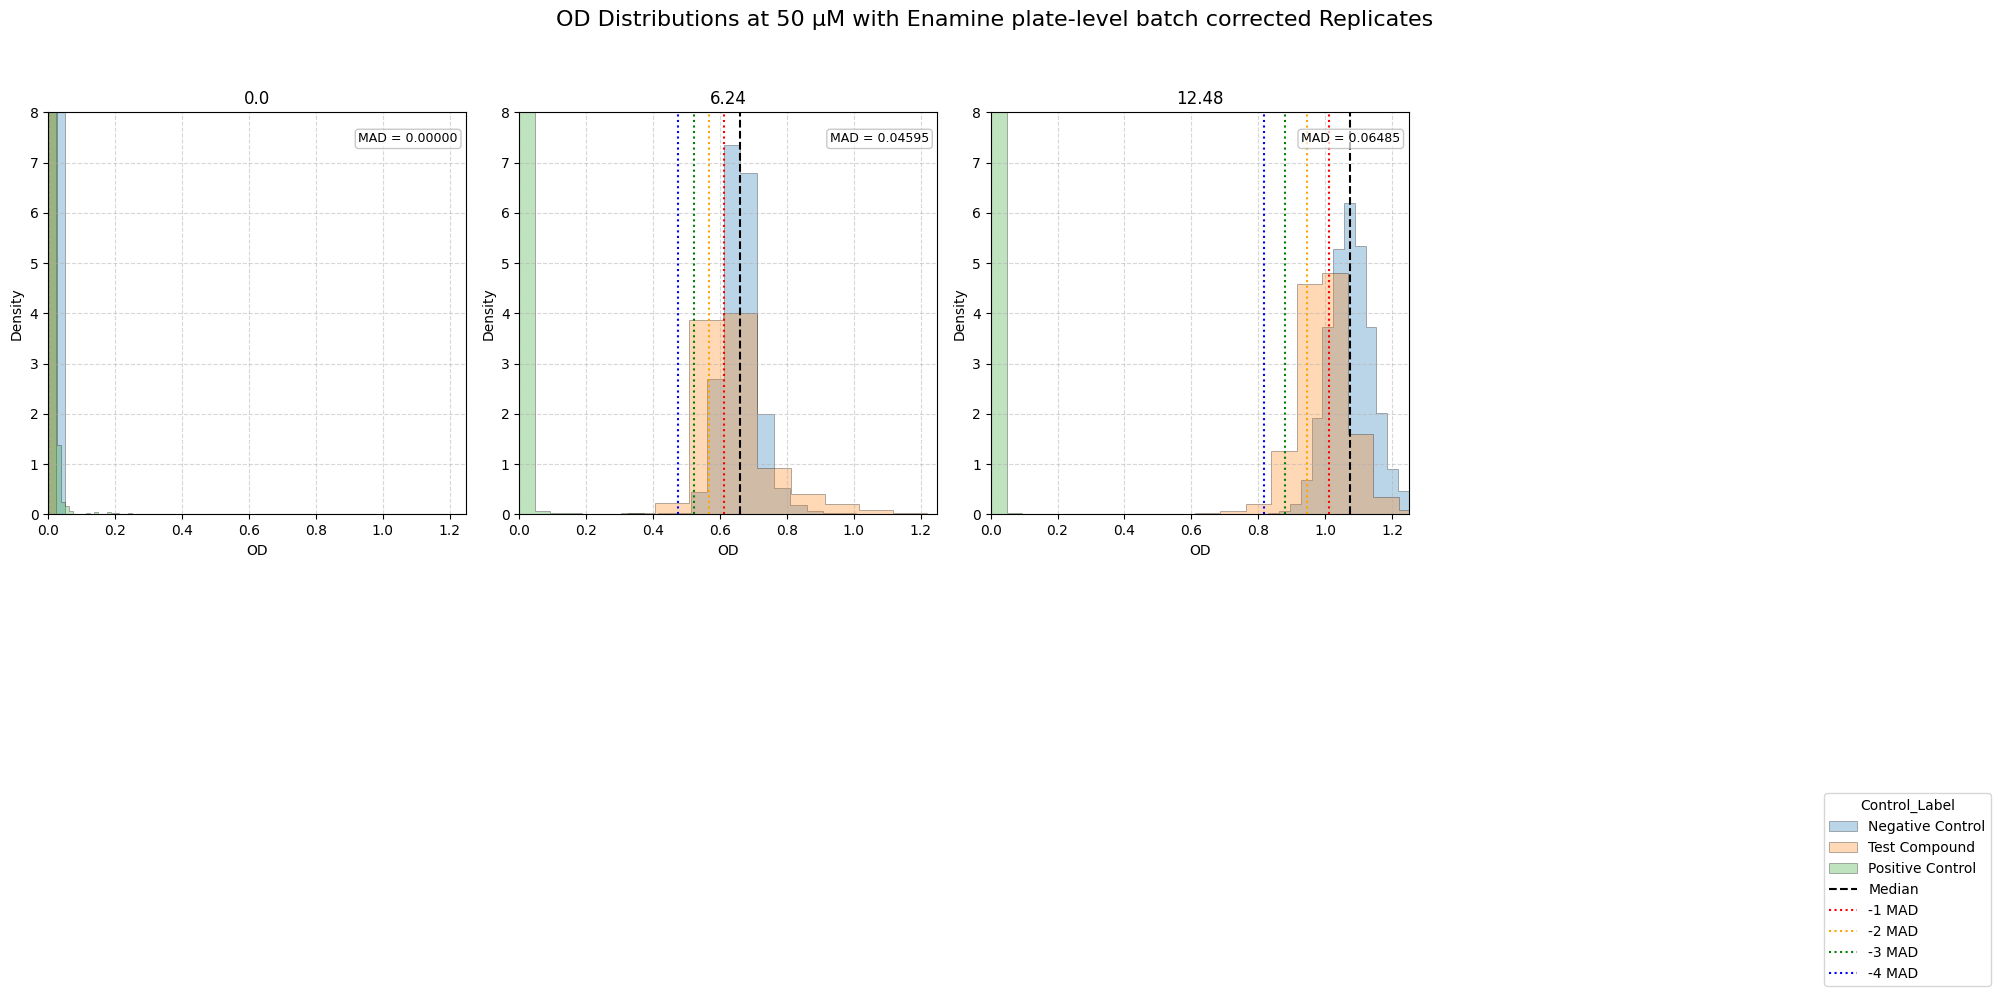

In [13]:
custom_bins = {
    -1: 20,  # Negative Control
     0: 20,  # Test Compound
     1: 20   # Positive Control (fewer samples, so fewer bins)
}

df_Enamine_plate_correction = correct_plate_batch_effect_dmso(df_Enamine.copy())

title='Enamine plate-level batch corrected Replicates'
concentrations=[50]
for c in concentrations:
    plot_hist_od_distributions_long_neg_ctrl_threshold(
        title,
        correct_uncorrect='Plate correction',
        dataset='df_Enamine_t6_t12',
        df_long=df_Enamine_plate_correction,
        concentration=c,
        bins=custom_bins, 
        max_x=1.25,
        max_density=8,
        save_path=False)

## Iterative well correction + labelling

Active-vs-inactive labels and the well-correction factor are interdependent: the
inactive subset defines the per-spot reference, but the threshold itself depends on
the corrected OD. The iterator alternates between (re)labelling and recomputing
well-correction factors on the *plate-corrected baseline* (factors are not
compounded across rounds), and stops when the fraction of label flips between
rounds drops below `tol`.

--- Initial labels (before any well correction) ---


/tmp/ipykernel_939084/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


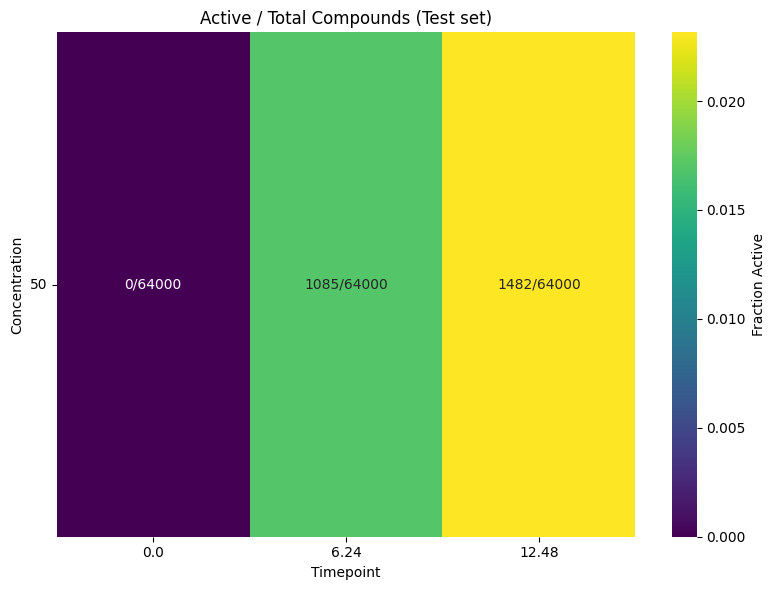

iter 1: flips=1192  (0.6208% of 192000 test rows)
--- Active labels after iter 1 ---


/tmp/ipykernel_939084/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


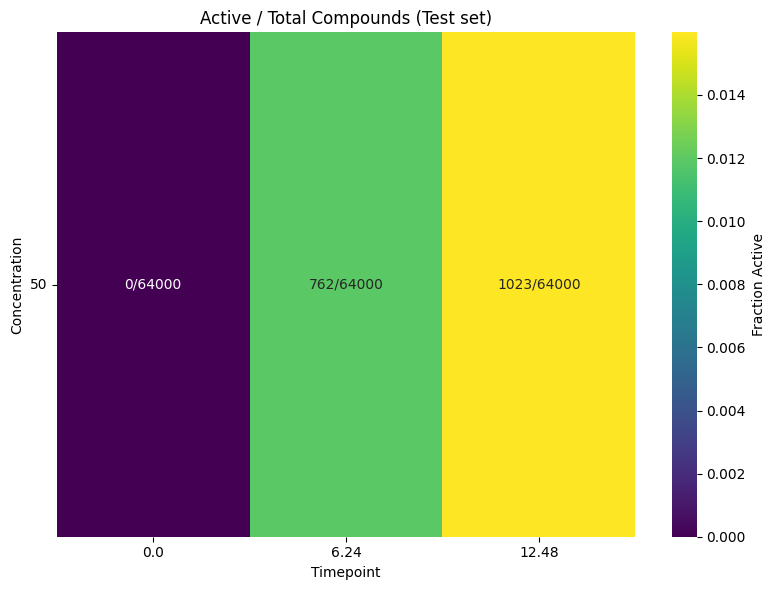

iter 2: flips=16  (0.0083% of 192000 test rows)
--- Active labels after iter 2 ---


/tmp/ipykernel_939084/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


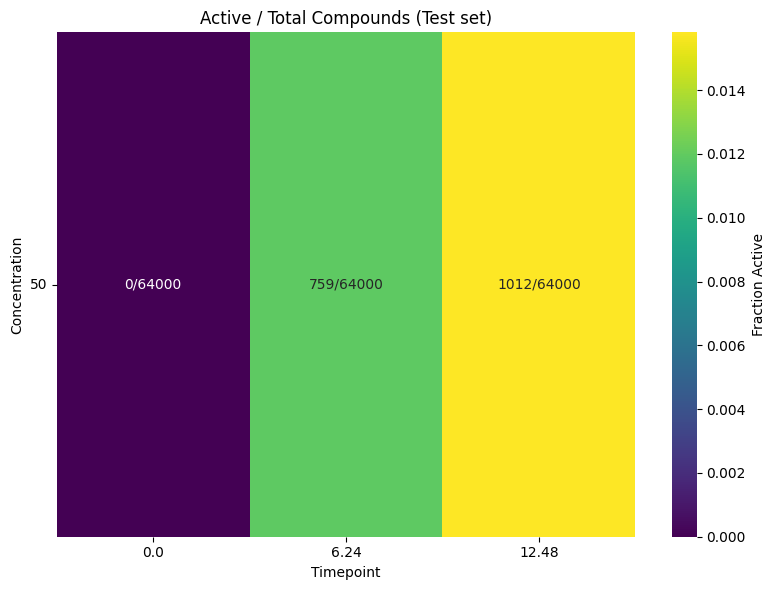

Converged at iter 2 (flip fraction < 0%).


In [14]:
df_Enamine_plate_well_corrected, flip_history = iterate_label_and_well_correct(
    df_Enamine_plate_correction,
    mad_multiplier=4,
    max_iters=10,
    tol=0.001,
    plot_each_iter=True,
)


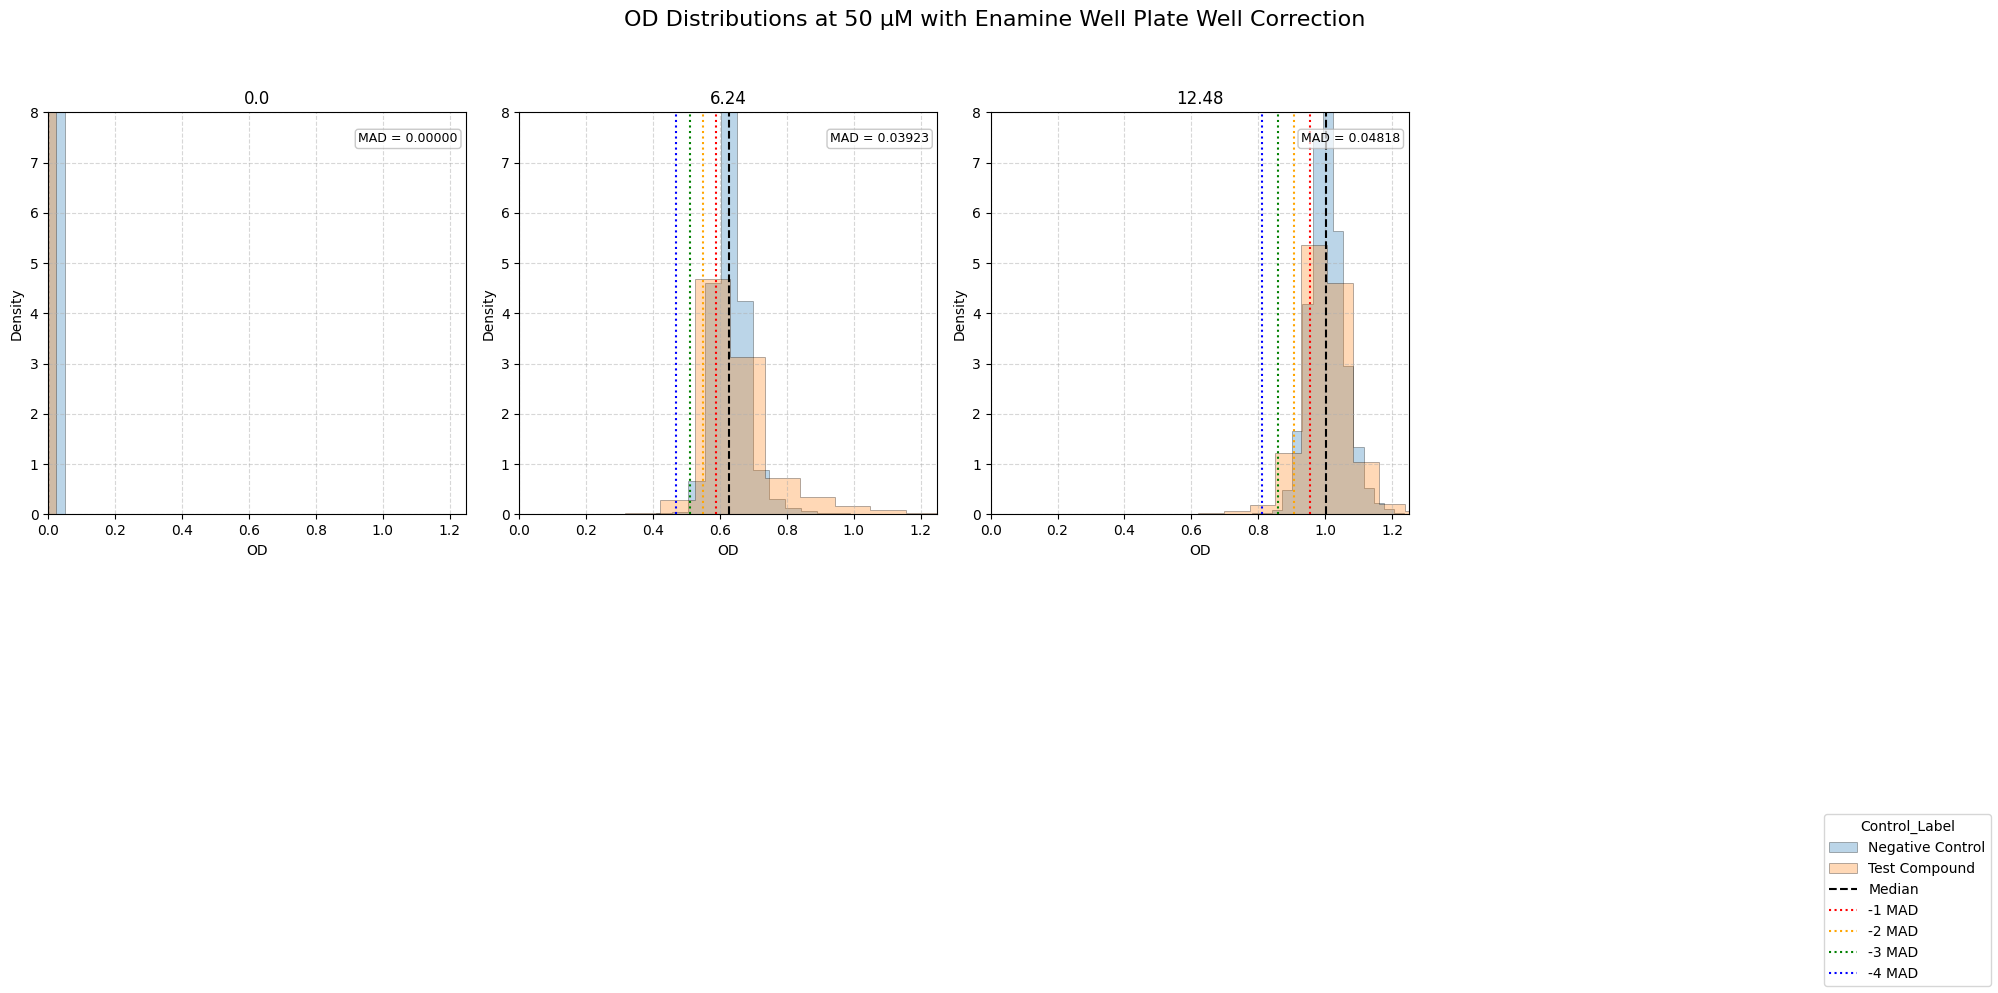

In [15]:
custom_bins = {
    -1: 20,                       # negatives
     0: 20,  # tests
     1: 20,                     # positives
}

title='Enamine Well Plate Well Correction'
concentrations=[50]
for c in concentrations:
    plot_hist_od_distributions_long_neg_ctrl_threshold(
        title,
        correct_uncorrect='correction_1',
        dataset='df_Enamine_t6_t12',
        df_long=df_Enamine_plate_well_corrected,
        concentration=c,
        bins=custom_bins, 
        max_x=1.25,
        max_density=8,
        plot_pos_ctrls=False,
        save_path=False
    )

/home/ethan2/GrowthNet/.venv/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


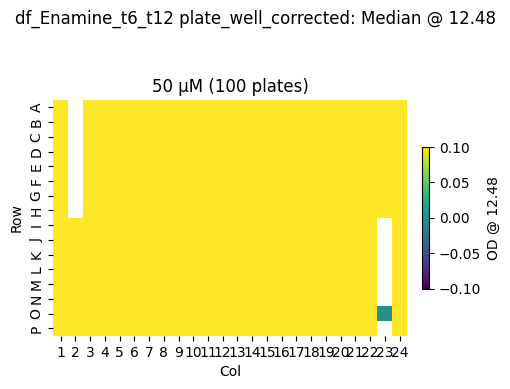

In [16]:
# Verify well correction worked: aggregated 384-well median heatmap at the late
# timepoint should look flatter than the uncorrected version above (no obvious
# row/column gradients).
plot_aggregated_heatmaps_long(
    correct_uncorrect='plate_well_corrected',
    dataset='df_Enamine_t6_t12',
    df_long=df_Enamine_plate_well_corrected,
    timepoint=12.48,
)


In [17]:
df_test_avg = (
      df_Enamine_plate_well_corrected[df_Enamine_plate_well_corrected['Control_Label'] == 0]                                          
        .groupby(['Plate_ID', 'Concentration', 'Compound',
  'Timepoint'], as_index=False)                                     
        .agg(     
            Control_Label = ('Control_Label', 'first'),
            OD            = ('OD', 'mean'),                         
            Smiles        = ('Smiles', 'first'),
        )                                                           
  ) 

# Controls: one row per (Plate, Well, Timepoint) — collapses replicates WITHIN a well
  # Keeping Well preserves the ~40 DMSO wells per plate so MAD is well-defined.  
  #                                                    
df_controls_avg = (
    df_Enamine_plate_well_corrected[df_Enamine_plate_well_corrected['Control_Label'] != 0]                                          
    .groupby(['Plate_ID', 'Well', 'Concentration', 'Compound',
'Timepoint'], as_index=False)                                     
    .agg(     
        Control_Label = ('Control_Label', 'first'),
        OD            = ('OD', 'mean'),                         
        Smiles        = ('Smiles', 'first'),
    )                                                           
)               

df_Enamine_plate_well_corrected_avg = pd.concat(                  
    [df_test_avg, df_controls_avg], ignore_index=True
) 

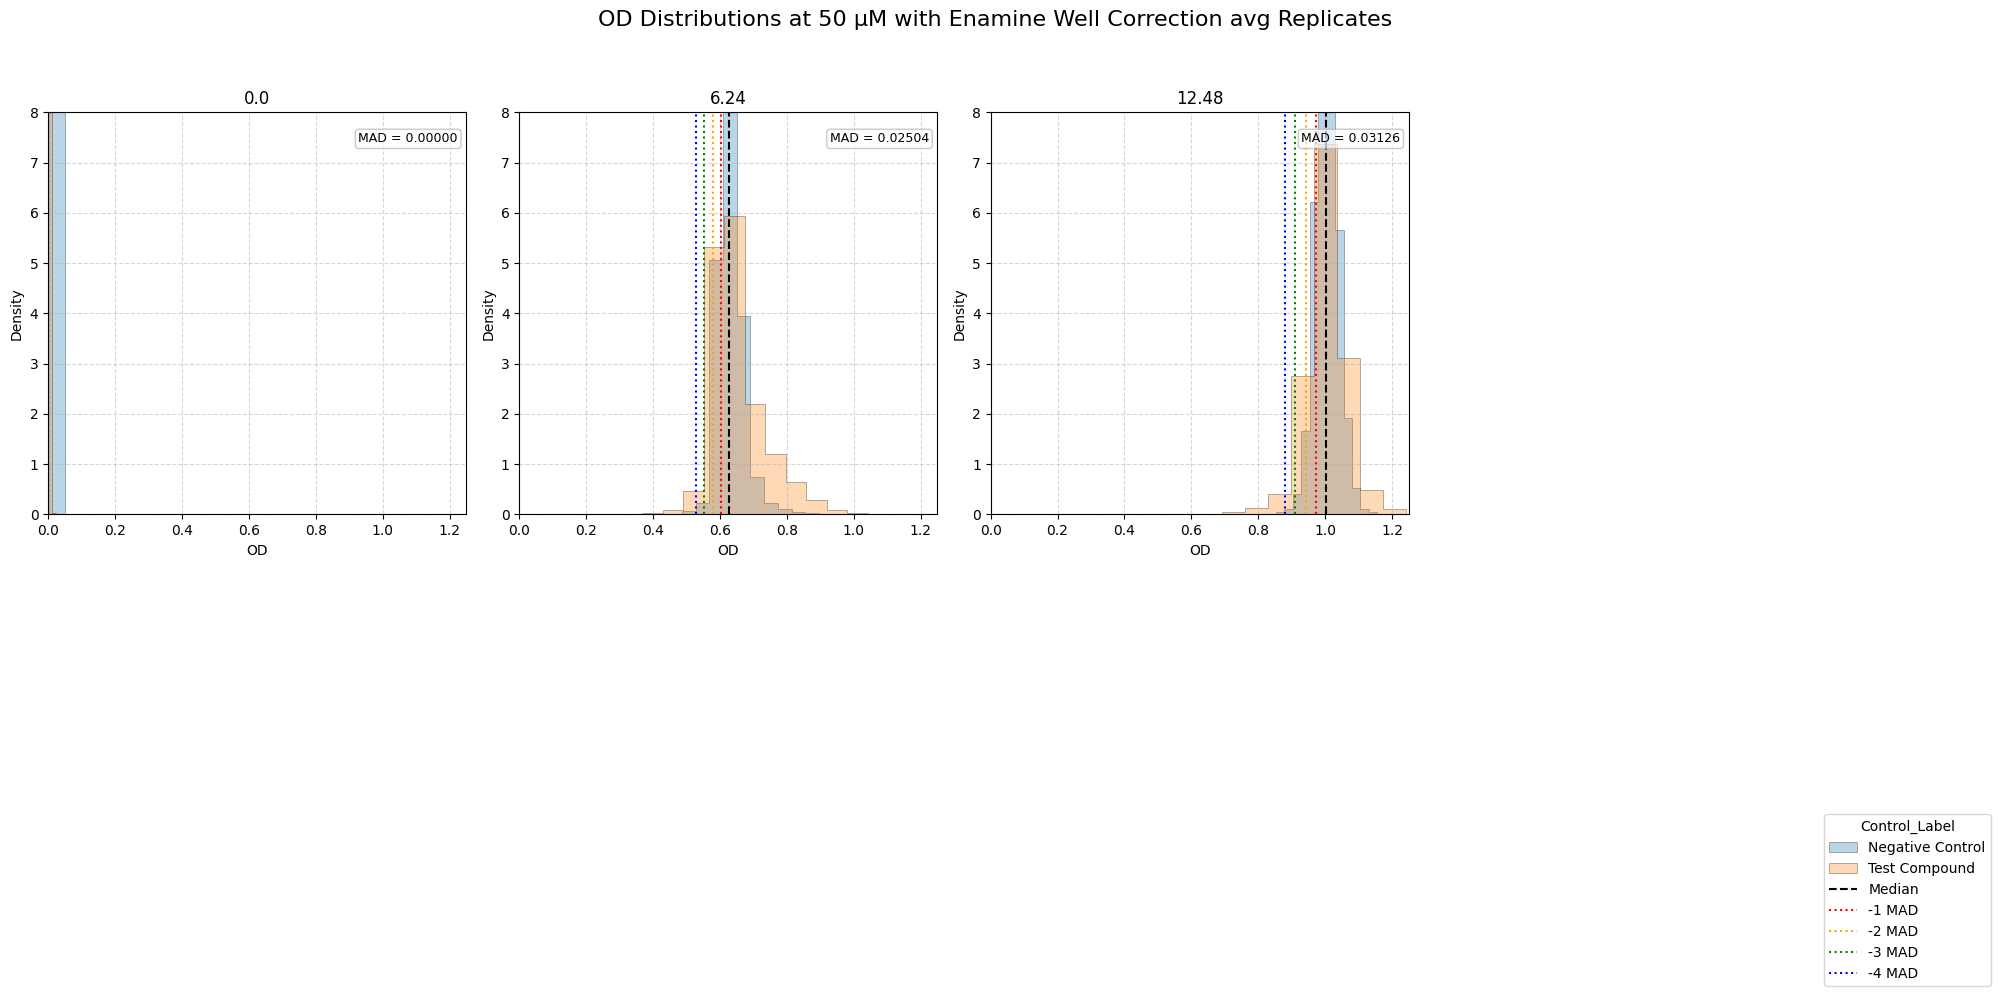

In [18]:
custom_bins = {
    -1: 20,                       # negatives
     0: 20,  # tests
     1: 20,                     # positives
}

title='Enamine Well Correction avg Replicates'
concentrations=[50]
for c in concentrations:
    plot_hist_od_distributions_long_neg_ctrl_threshold(
        title,
        correct_uncorrect='correction_1',
        dataset='df_Enamine_t6_t12',
        df_long=df_Enamine_plate_well_corrected_avg,
        concentration=c,
        bins=custom_bins, 
        max_x=1.25,
        max_density=8,
        plot_pos_ctrls=False,
        save_path=False
    )

/tmp/ipykernel_939084/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


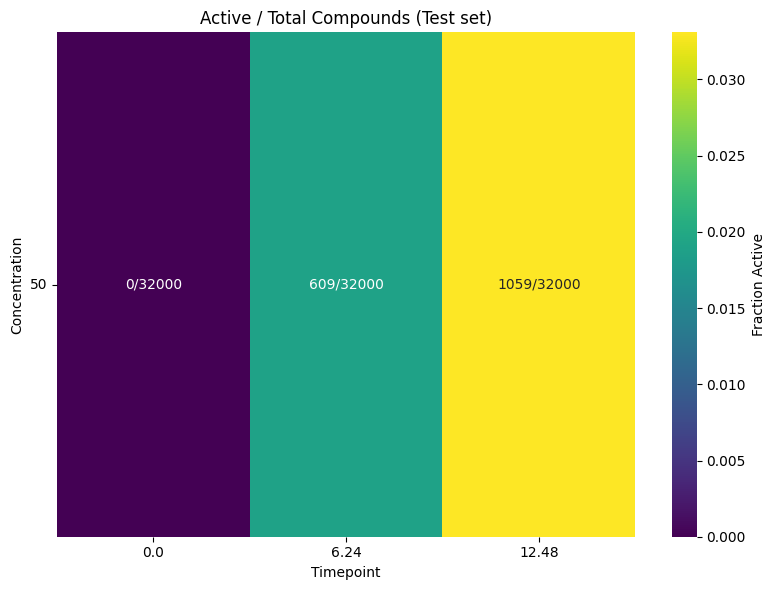

In [20]:
df_Enamine_plate_well_corrected_avg = label_inactives_actives(df_Enamine_plate_well_corrected_avg, mad_multiplier=4)
plot_activity_ratio_heatmap(df_Enamine_plate_well_corrected_avg[df_Enamine_plate_well_corrected_avg['Control_Label'] == 0])